In [2]:
# CELL 1 — Connect Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# CELL 2 — Setting up Paths
DATASET_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset"

SAVE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Task3_Results"

import os
print("Classes found:", os.listdir(DATASET_PATH))

Classes found: ['urooj', 'Dilkash', 'Akbar']


In [7]:
# CELL 3 — Importing required Liraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization, Activation)
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
# CELL 4 — Define Hyperparameters
IMG_SIZE    = (64, 64)   # Reduced from 224x224 — essential for small datasets
BATCH_SIZE  = 16         # Smaller batch = more frequent weight updates = better for small data
EPOCHS      = 60         # Max epochs — EarlyStopping will interrupt early if needed
LR          = 0.0001     # Adam learning rate — kept same as Task 2 for consistency
NUM_CLASSES = 3          # Akbar, Dilkash, Urooj

print("Hyperparameters:")
print(f"  Image Size   : {IMG_SIZE}")
print(f"  Batch Size   : {BATCH_SIZE}")
print(f"  Max Epochs   : {EPOCHS}")
print(f"  Learning Rate: {LR}")
print(f"  Num Classes  : {NUM_CLASSES}")

Hyperparameters:
  Image Size   : (64, 64)
  Batch Size   : 16
  Max Epochs   : 60
  Learning Rate: 0.0001
  Num Classes  : 3


In [23]:
# CELL 5 — Data Loading with Augmentation
# ── Training Generator (WITH augmentation) ───────────────────────────────────
SEED=42
train_datagen = ImageDataGenerator(
    rescale            = 1./255,        # Normalize pixel values from 0-255 to 0-1
    validation_split   = 0.3,           # Keep 30% aside for validation + test
    horizontal_flip    = True,          # Randomly flip images horizontally
    rotation_range     = 20,            # Randomly rotate up to ±20 degrees
    zoom_range         = 0.15,          # Randomly zoom in/out up to 15%
    width_shift_range  = 0.1,           # Shift horizontally up to 10% of width
    height_shift_range = 0.1,           # Shift vertically up to 10% of height
    brightness_range   = [0.8, 1.2]     # Vary brightness between 80% and 120%
)

# ── Load 70% as Training Data ─────────────────────────────────────────────────
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = SEED
)

# ── Load 30% as Temp Data (for splitting into Val + Test) ─────────────────────
# Note: We use a clean datagen (no augmentation) to get true file paths and labels
temp_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)
temp_data = temp_datagen.flow_from_directory(
    DATASET_PATH,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False              # Keep order fixed for correct label alignment
)

class_names = list(train_data.class_indices.keys())
print("Class names    :", class_names)
print("Class indices  :", train_data.class_indices)
print(f"Training images: {train_data.samples}")
print(f"Temp images    : {temp_data.samples}")

Found 788 images belonging to 3 classes.
Found 336 images belonging to 3 classes.
Class names    : ['Akbar', 'Dilkash', 'urooj']
Class indices  : {'Akbar': 0, 'Dilkash': 1, 'urooj': 2}
Training images: 788
Temp images    : 336


In [13]:
# CELL 6 — Split TEMP into Validation (10%) and Test (20%)
X = np.array(temp_data.filepaths)
y = temp_data.classes

# 1/3 of 30% → 10% val  |  2/3 of 30% → 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X, y,
    test_size    = 2/3,       # 2/3 of the 30% temp = 20% of total
    random_state = SEED,      # Reproducible split
    stratify     = y          # Maintain class balance in both splits
)

print(f"Validation samples : {len(X_val)}  (~10% of total)")
print(f"Test samples       : {len(X_test)} (~20% of total)")


Validation samples : 112  (~10% of total)
Test samples       : 224 (~20% of total)


In [14]:
# CELL 7 — Create Validation & Test Generators
eval_datagen = ImageDataGenerator(rescale=1./255)  # No augmentation for eval

# ── Validation DataFrame
val_df = pd.DataFrame({
    "filename": X_val,
    "class"   : [class_names[i] for i in y_val]   # Map integers → class name strings
})

# ── Test DataFrame
test_df = pd.DataFrame({
    "filename": X_test,
    "class"   : [class_names[i] for i in y_test]
})

# ── Validation Generator
val_data = eval_datagen.flow_from_dataframe(
    val_df,
    x_col       = "filename",
    y_col       = "class",
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False          # CRITICAL: never shuffle eval data
)

# ── Test Generator
test_data = eval_datagen.flow_from_dataframe(
    test_df,
    x_col       = "filename",
    y_col       = "class",
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False
)

print("Val  generator :", val_data.samples,  "samples")
print("Test generator :", test_data.samples, "samples")
print("Class mapping  :", test_data.class_indices)

Found 112 validated image filenames belonging to 3 classes.
Found 224 validated image filenames belonging to 3 classes.
Val  generator : 112 samples
Test generator : 224 samples
Class mapping  : {'Akbar': 0, 'Dilkash': 1, 'urooj': 2}


In [15]:
# CELL 8 — Building Custom CNN Model
model = Sequential([

    # ── Block 1: Basic Feature Extraction (edges, textures) ──────────────────
    Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),   # Normalize → stable, faster training
    Activation('relu'),     # Non-linear activation
    MaxPooling2D(2, 2),     # 64×64 → 32×32

    # ── Block 2: Intermediate Feature Extraction (shapes, patterns) ───────────
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),     # 32×32 → 16×16

    # ── Block 3: High-level Feature Extraction (class-specific features) ──────
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),     # 16×16 → 8×8

    # ── Classifier Head ───────────────────────────────────────────────────────
    Flatten(),              # 8×8×128 = 8,192-dim feature vector
    Dense(256),             # 256 neurons for rich feature combination
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),           # Drop 50% of neurons → reduce overfitting on small dataset

    # ── Output Layer ──────────────────────────────────────────────────────────
    Dense(NUM_CLASSES, activation='softmax')   # P(class) for each of 3 classes
], name="Custom_CNN")

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=LR),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,347 (8.37 MB)

 Trainable params: 2,192,387 (8.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
# CELL 9 — Early Stopping
early_stop = EarlyStopping(
    monitor              = 'val_loss',   # Watch validation loss
    patience             = 10,           # Stop after 10 epochs of no improvement
    restore_best_weights = True,         # Use the best epoch's weights for evaluation
    verbose              = 1            # Print a message when early stopping triggers
)

print("EarlyStopping configured successfully")
print("  Monitoring : val_loss")
print("  Patience   : 10 epochs")
print("  Will restore best weights automatically")

EarlyStopping configured successfully
  Monitoring : val_loss
  Patience   : 10 epochs
  Will restore best weights automatically


In [17]:
# CELL 10 — Model Training
print("Starting Custom CNN training...")
print(f"Train: {train_data.samples} images | Val: {val_data.samples} images")
print("-" * 55)

start_time = time.time()

history = model.fit(
    train_data,
    validation_data = val_data,      # Monitor val_loss — never used for gradient updates
    epochs          = EPOCHS,        # Max 60 epochs
    callbacks       = [early_stop],  # Stop early if val_loss stops improving
    verbose         = 1
)

train_time = time.time() - start_time
actual_epochs = len(history.history['loss'])

print(f"\nTraining finished!")
print(f"  Total training time : {train_time:.2f} seconds")
print(f"  Actual epochs run   : {actual_epochs} / {EPOCHS}")
print(f"  Best val_accuracy   : {max(history.history['val_accuracy']):.4f}")
print(f"  Best val_loss       : {min(history.history['val_loss']):.4f}")

Starting Custom CNN training...
Train: 788 images | Val: 112 images
-------------------------------------------------------
Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.6739 - loss: 0.7040 - val_accuracy: 0.3304 - val_loss: 2.0665
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 322ms/step - accuracy: 0.7195 - loss: 0.5623 - val_accuracy: 0.3304 - val_loss: 3.0196
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 323ms/step - accuracy: 0.7246 - loss: 0.5718 - val_accuracy: 0.3304 - val_loss: 3.5608
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 319ms/step - accuracy: 0.7322 - loss: 0.5322 - val_accuracy: 0.3304 - val_loss: 3.6685
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 323ms/step - accuracy: 0.7373 - loss: 0.5036 - val_accuracy: 0.3304 - val_loss: 3.6068
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 319ms/step - accuracy: 0.7373 - loss: 0.5104 - val_accuracy: 0.3304 - val_loss: 3.8587
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 322ms/step - accuracy: 0.7437 - loss: 0.4730 - val_accuracy: 0

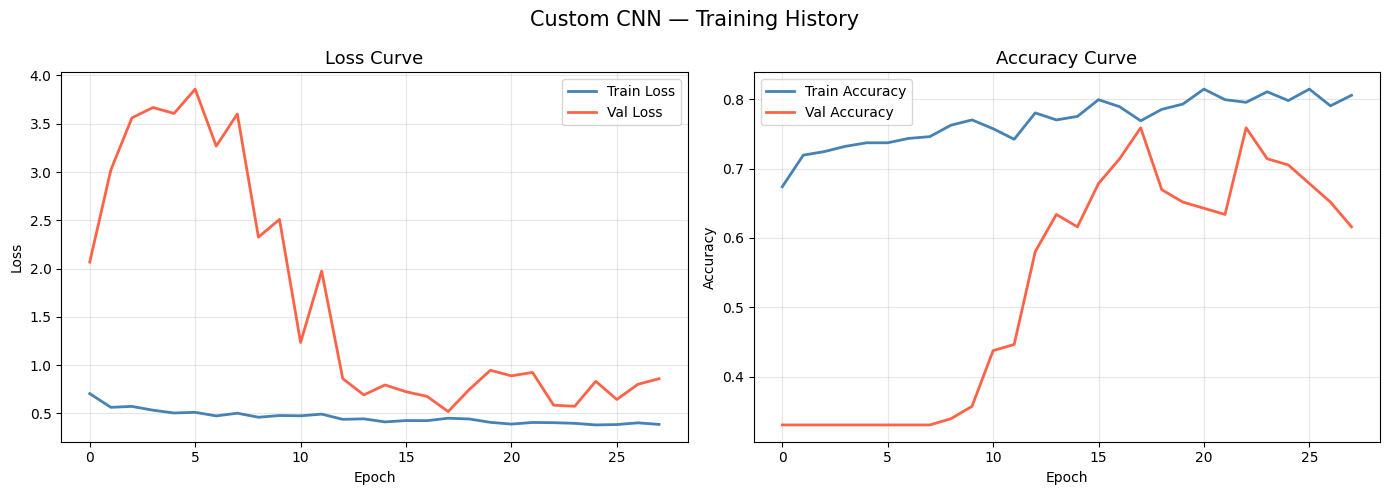

In [18]:
# CELL 11 — Training Graphs (Ploting Training and Validation Loss(Monitoring Overfitting))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss Curve
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato', linewidth=2)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy Curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='tomato',    linewidth=2)
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN — Training History', fontsize=15)
plt.tight_layout()
plt.show()

In [19]:
# CELL 12 — Generate Test Predictions
print("Generating predictions on test set...")

start_test = time.time()
y_pred_probs  = model.predict(test_data, verbose=1)
testing_time  = time.time() - start_test

# Convert probability scores to class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = test_data.classes

print(f"\nTesting completed in {testing_time:.4f} seconds")
print(f"Unique predicted classes : {np.unique(y_pred_classes)}")  # Should show 0, 1, 2
print(f"Unique true classes      : {np.unique(y_true_classes)}")  # Should show 0, 1, 2

# Verify all 3 classes are being predicted (not collapsed to 1)
pred_counts = dict(zip(*np.unique(y_pred_classes, return_counts=True)))
print("\nPrediction distribution:")
for idx, count in pred_counts.items():
    print(f"  {class_names[idx]:10s}: {count} predictions")

Generating predictions on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step

Testing completed in 56.0895 seconds
Unique predicted classes : [0 1 2]
Unique true classes      : [0 1 2]

Prediction distribution:
  Akbar     : 74 predictions
  Dilkash   : 39 predictions
  urooj     : 111 predictions


In [ ]:
# CELL 13 — Metrics(Evaluation)
# Overall Metrics
accuracy  = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
recall    = recall_score(y_true_classes,    y_pred_classes, average='weighted', zero_division=0)
f1        = f1_score(y_true_classes,        y_pred_classes, average='weighted', zero_division=0)

# AUC needs binarized labels for multi-class (One-vs-Rest)
y_true_bin = label_binarize(y_true_classes, classes=[0, 1, 2])
auc_score  = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')

# Per-Class Accuracy from Confusion Matrix Diagonal
cm_eval   = confusion_matrix(y_true_classes, y_pred_classes)
class_acc = cm_eval.diagonal() / cm_eval.sum(axis=1)

# Print Results
print("=" * 48)
print("        CUSTOM CNN — EVALUATION RESULTS")
print("=" * 48)
print(f"  Overall Accuracy : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision        : {precision:.4f}")
print(f"  Recall           : {recall:.4f}")
print(f"  F1-score         : {f1:.4f}")
print(f"  AUC              : {auc_score:.4f}")
print(f"  Training Time    : {train_time:.2f} sec")
print(f"  Testing Time     : {testing_time:.4f} sec")
print("-" * 48)

        CUSTOM CNN — EVALUATION RESULTS
  Overall Accuracy : 0.8214  (82.14%)
  Precision        : 0.8374
  Recall           : 0.8214
  F1-score         : 0.8253
  AUC              : 0.9156
  Training Time    : 230.92 sec
  Testing Time     : 1.7296 sec
------------------------------------------------


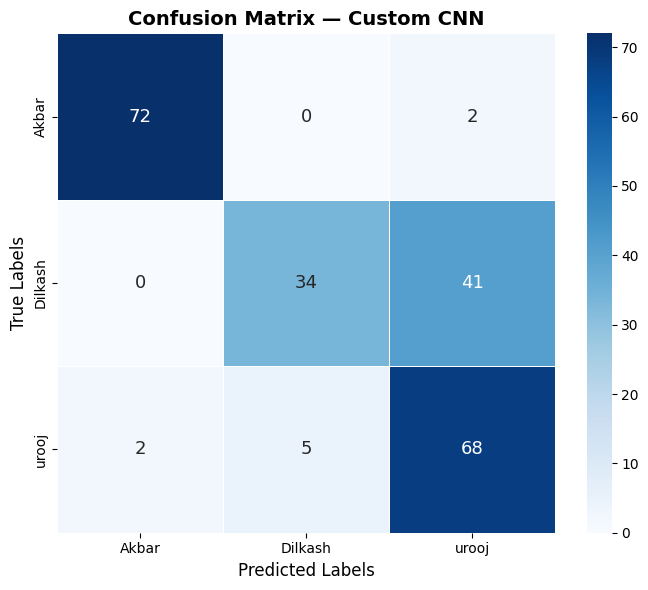


Confusion Matrix (rows=True class, cols=Predicted class):
         Akbar  Dilkash  urooj
Akbar       72        0      2
Dilkash      0       34     41
urooj        2        5     68


In [20]:
# CELL 14 — Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = "d",
    cmap        = "Blues",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.5,
    annot_kws   = {"size": 13}
)
plt.xlabel("Predicted Labels", fontsize=12)
plt.ylabel("True Labels",      fontsize=12)
plt.title("Confusion Matrix — Custom CNN", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Text version for logging
print("\nConfusion Matrix (rows=True class, cols=Predicted class):")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

In [21]:
# CELL 15 — Classification Report
print("Classification Report — Custom CNN:")
print("-" * 52)
print(classification_report(
    y_true_classes,
    y_pred_classes,
    target_names  = class_names,
    digits        = 4,
    zero_division = 0
))

Classification Report — Custom CNN:
----------------------------------------------------
              precision    recall  f1-score   support

       Akbar     0.9730    0.9730    0.9730        74
     Dilkash     0.8718    0.4533    0.5965        75
       urooj     0.6126    0.9067    0.7312        75

    accuracy                         0.7768       224
   macro avg     0.8191    0.7777    0.7669       224
weighted avg     0.8184    0.7768    0.7660       224



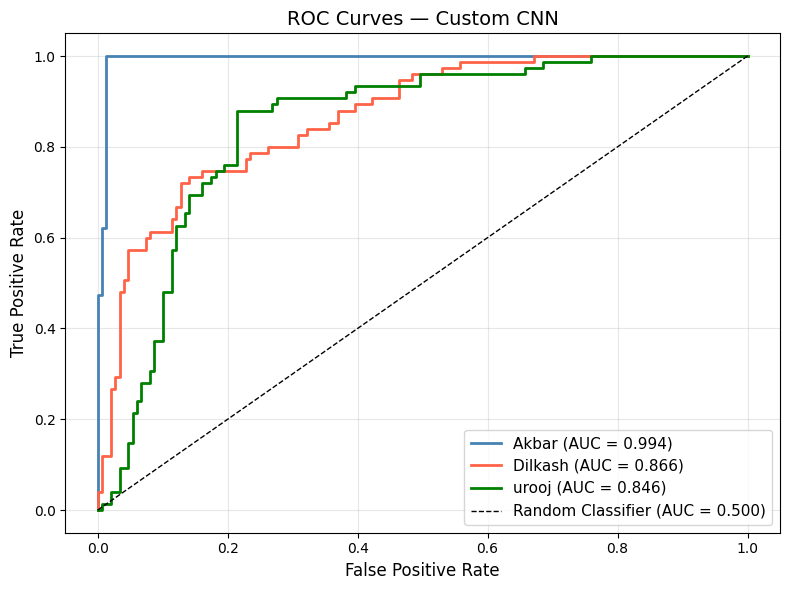

Per-class AUC:
  Akbar       : 0.9940
  Dilkash     : 0.8660
  urooj       : 0.8459
  Weighted Avg  : 0.9016


In [25]:
# CELL 16 — ROC Curves & AUC
y_true_bin = label_binarize(y_true_classes, classes=list(range(NUM_CLASSES))) # Define y_true_bin

fpr, tpr, roc_auc_dict = {}, {}, {}

for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc_dict[i]   = auc(fpr[i], tpr[i])

# Re-calculate auc_score here to ensure it's defined
auc_score  = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')

colors = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    plt.plot(fpr[i], tpr[i], color=colors[i], linewidth=2,
             label=f"{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate",  fontsize=12)
plt.title("ROC Curves — Custom CNN", fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Per-class AUC:")
for i in range(NUM_CLASSES):
    print(f"  {class_names[i]:12s}: {roc_auc_dict[i]:.4f}")
print(f"  Weighted Avg  : {auc_score:.4f}")

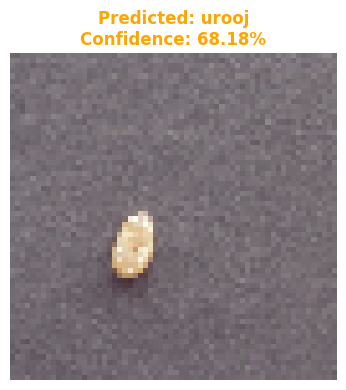


Class Probabilities:
  Akbar       :   0.46%  
  Dilkash     :  31.36%  ████████████
  urooj       :  68.18%  ███████████████████████████


In [26]:
# CELL 17 — Single Image Prediction
from tensorflow.keras.preprocessing import image as keras_image

# ── Change this path to any wheat seed image on your Drive
TEST_IMAGE_PATH = "/content/drive/MyDrive/AI_Project_CSE366/Wheat varieties dataset/Dilkash/D100/Dilkash (298).jpg"
img       = keras_image.load_img(TEST_IMAGE_PATH, target_size=IMG_SIZE)
img_array = keras_image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

predictions           = model.predict(img_array, verbose=0)
predicted_class_index = np.argmax(predictions[0])
confidence            = np.max(predictions[0]) * 100
predicted_class_name  = class_names[predicted_class_index]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name}\nConfidence: {confidence:.2f}%",
          fontsize=12, fontweight='bold',
          color='green' if confidence > 70 else 'orange')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nClass Probabilities:")
for i, label in enumerate(class_names):
    bar = '█' * int(predictions[0][i] * 40)
    print(f"  {label:12s}: {predictions[0][i]*100:6.2f}%  {bar}")

In [28]:
os.makedirs(SAVE_PATH, exist_ok=True)

MODEL_NAME = "customcnn"

# Correctness array
correct_array = (y_pred_classes == y_true_classes).astype(int)
np.save(f"{SAVE_PATH}/{MODEL_NAME}_correct.npy", correct_array)

#  compute metrics
accuracy  = accuracy_score(y_true_classes, y_pred_classes)
precision = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
recall    = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
f1        = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)

y_true_bin = label_binarize(y_true_classes, classes=[0,1,2])
auc_score  = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')

#  Metrics CSV
metrics_df = pd.DataFrame({
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1-score": [f1],
    "AUC": [auc_score],
    "Training Time (sec)": [train_time],
    "Testing Time (sec)": [testing_time]
})

metrics_df.to_csv(f"{SAVE_PATH}/{MODEL_NAME}_metrics.csv", index=False)

print(" All results saved successfully!")

 All results saved successfully!
